In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torchvision import models
from torch.amp.grad_scaler import GradScaler
from torch.amp.autocast_mode import autocast
import numpy as np
from tqdm import tqdm
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler


In [2]:
import sys
sys.path.append("/mnt/Personal/Projects/Autofocus/Code/Universal")

In [3]:
import pytorch_start # type: ignore
pytorch_start.activate_gpu(print_details=True)


                               ACTIVE GPU CONFIGURATION                              
+-------------+------------------------------------+---------------+--------------+---------------+
|   Device ID | Name                               |   Memory (GB) | PCI Bus ID   | GFX Version   |
+=============+====================================+===============+==============+===============+
|           0 | NVIDIA GeForce RTX 3050 Laptop GPU |          3.69 | Unknown      | Native        |
+-------------+------------------------------------+---------------+--------------+---------------+

Configured GPU 0: _CudaDeviceProperties(name='NVIDIA GeForce RTX 3050 Laptop GPU', major=8, minor=6, total_memory=3778MB, multi_processor_count=16, uuid=1fb0444c-042f-2836-2dde-93bbe9dca9b5, L2_cache_size=1MB)


In [4]:
dataset_type = "Test"
dataset_path = "/mnt/Velocity_Vault/Datasets/Autofocus/Dataset/"+dataset_type
model_path = "/mnt/Velocity_Vault/Datasets/Autofocus/Model/"

label_path = dataset_path+"/label.mm"
patch_path = dataset_path+"/patch.mm"

meta_data_path = dataset_path+"/meta.txt"

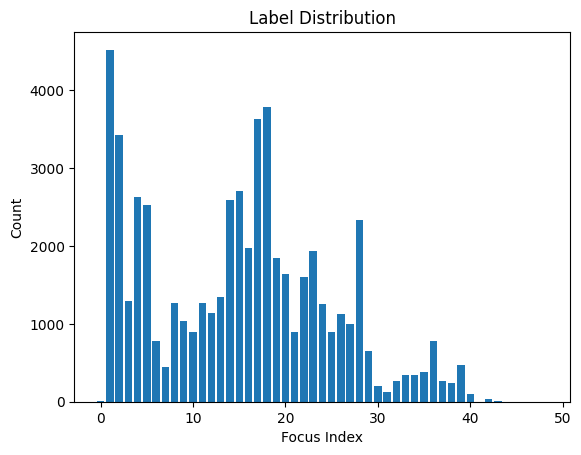

In [5]:
with open(meta_data_path, "r") as f:
    meta_data = json.load(f)
        
labels = np.memmap(label_path, dtype=np.uint8, mode='r')

hist = np.bincount(labels, minlength=49)

plt.bar(range(49), hist)
plt.title("Label Distribution")
plt.xlabel("Focus Index")
plt.ylabel("Count")
plt.show()

In [6]:

# -----------------------------
# 1. Dataset (Optimized Memmap)
# -----------------------------
class FocalStackDataset(Dataset):
    def __init__(self, patches_path, labels_path, shape): 
        
        self.patches = np.memmap(
            patches_path,
            dtype=np.uint8,
            mode='r',
            shape=shape
        )

        self.labels = np.memmap(
            labels_path,
            dtype=np.uint8,
            mode='r',
            shape=(shape[0],)
        )

    def __len__(self):
        return self.patches.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.patches[idx]).contiguous()
        y = torch.as_tensor(self.labels[idx], dtype=torch.long)

        return x, y


In [7]:


# -----------------------------
# 2. Model
# -----------------------------
class MobileNetV2_Focus(nn.Module):
    def __init__(self):
        super().__init__()

        base = models.mobilenet_v2(weights=None, width_mult=4.0)

        # Directly access conv layer
        original_conv = base.features[0][0]

        base.features[0][0] = nn.Conv2d(
            in_channels=49,
            out_channels=original_conv.out_channels, # type: ignore
            kernel_size=original_conv.kernel_size, # type: ignore
            stride=original_conv.stride, # type: ignore
            padding=original_conv.padding, # type: ignore
            bias=False
        )

        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Linear(base.last_channel, 49)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


In [8]:


# -----------------------------
# 3. Ordinal Loss
# -----------------------------
def ordinal_loss(pred, target, class_weights, class_range, sigma):
    
    target_exp = target.unsqueeze(1).float()

    dist = torch.abs(class_range - target_exp)
    soft_labels = torch.exp(-dist / sigma)
    soft_labels = soft_labels / soft_labels.sum(dim=1, keepdim=True)

    log_probs = nn.functional.log_softmax(pred, dim=1)

    # Apply weights
    sample_weights = class_weights[target]  # (B,)

    loss = -(soft_labels * log_probs).sum(dim=1)
    loss = (loss * sample_weights).mean()

    return loss



In [9]:
def train_epoch(model, loader, optimizer, scaler, device, class_weights, class_range, sigma, acc_k):
    model.train()
    total_loss = 0.0
    total_mae = 0.0
    total_acck = 0.0
    
    pbar = tqdm(loader, desc="Training", leave=True)

    for x, y in pbar:
        
        x = x.to(device, non_blocking=True)\
             .to(memory_format=torch.channels_last)\
             .float().div_(127.5).sub_(1.0)

        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # AMP forward + loss
        with autocast(device_type="cuda"):
            outputs = model(x)
            loss = ordinal_loss(
                outputs,
                y,
                class_weights=class_weights,
                class_range=class_range,
                sigma=sigma
            )

        # AMP backward
        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        # ---- metrics ----
        total_loss += loss.item()

        pred = outputs.argmax(dim=1)

        # MAE
        mae = (pred - y).abs().float().mean()
        total_mae += mae.item()

        acck = ((pred - y).abs() <= acc_k).float().mean()
        total_acck += acck.item()

        # running averages
        avg_loss = total_loss / (pbar.n + 1)
        avg_mae = total_mae / (pbar.n + 1)
        avg_acck = total_acck / (pbar.n + 1)

        pbar.set_postfix(
            loss=avg_loss,
            mae=avg_mae,
            acck=avg_acck
        )

    return total_loss / len(loader)

In [10]:



# -----------------------------
# 5. Main Training Script
# -----------------------------
import numpy as np
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch.optim as optim
from torch.amp.grad_scaler import GradScaler


# -----------------------------
# 1. Device
# -----------------------------
def get_device():
    return torch.device("cuda")


# -----------------------------
# 2. Dataset + Labels
# -----------------------------
def load_dataset_and_labels(patches_path, labels_path, shape):
    dataset = FocalStackDataset(patches_path, labels_path, shape)

    labels_memmap = np.memmap(
        labels_path,
        dtype=np.uint8,
        mode='r',
        shape=(shape[0],)
    )

    labels_np = np.array(labels_memmap)

    return dataset, labels_np


# -----------------------------
# 3. Compute Weights (safe for missing classes)
# -----------------------------
def compute_class_weights(labels_np, device, num_classes=49):
    hist = np.bincount(labels_np, minlength=num_classes)
    valid_mask = hist > 0

    weights = np.zeros_like(hist, dtype=np.float32)
    weights[valid_mask] = 1.0 / hist[valid_mask]

    weights = weights / weights.sum() * valid_mask.sum()

    class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

    return weights, class_weights


# -----------------------------
# 4. Sampler + DataLoader
# -----------------------------
# def create_dataloader(dataset, labels_np, weights, batch_size):
def create_dataloader(dataset, batch_size):
    
    # sample_weights = weights[labels_np]

    # sampler = WeightedRandomSampler(
    #     weights=sample_weights.tolist(),
    #     num_samples=len(sample_weights),
    #     replacement=True
    # )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        pin_memory_device="cuda",
        persistent_workers=True,
        prefetch_factor=1
    )

    return loader



In [11]:


# -----------------------------
# 5. Model + Optimizer + AMP
# -----------------------------
def setup_training(device):
    model = MobileNetV2_Focus().to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    scaler = GradScaler()

    return model, optimizer, scaler


# -----------------------------
# 6. Scheduler
# -----------------------------
def create_scheduler(optimizer, epochs):
    return torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

def save_checkpoint(model, optimizer, epoch, loss, path):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": loss
    }, path)
    
# -----------------------------
# 7. Training Loop
# -----------------------------
import os

def run_training(
    model,
    loader,
    optimizer,
    scaler,
    scheduler,
    device,
    class_weights,
    sigma,
    epochs,
    acc_k,
    save_dir,
    save_every_k=5
):
    os.makedirs(save_dir, exist_ok=True)

    best_loss = float("inf")
    
    class_range = torch.arange(49, device=device).float()

    for epoch in range(epochs):
        loss = train_epoch(
            model,
            loader,
            optimizer,
            scaler,
            device,
            class_weights,
            class_range,
            sigma,
            acc_k
        )

        scheduler.step()

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {loss:.4f}")

        # ---- Save periodic checkpoint ----
        if (epoch + 1) % save_every_k == 0:
            save_path = os.path.join(save_dir, f"checkpoint_epoch_{epoch+1}.pth")
            save_checkpoint(model, optimizer, epoch+1, loss, save_path)

        # ---- Save best model ----
        if loss < best_loss:
            best_loss = loss
            best_path = os.path.join(save_dir, "best_model.pth")
            torch.save(model.state_dict(), best_path)

    # ---- Save final model ----
    final_path = os.path.join(save_dir, "final_model.pth")
    torch.save(model.state_dict(), final_path)


In [12]:



# -----------------------------
# 8. Main
# -----------------------------
def execution(patches_path,labels_path,train_shape,sigma,EPOCHS,batch_size,save_every_k,save_dir,acck):

    # train_shape = (N, 49, 128, 128)

    device = get_device()

    dataset, labels_np = load_dataset_and_labels(
        patches_path,
        labels_path,
        train_shape
    )

    weights, class_weights = compute_class_weights(labels_np, device)

    # train_loader = create_dataloader(dataset, labels_np, weights, batch_size=batch_size)
    train_loader = create_dataloader(dataset, batch_size=batch_size)

    model, optimizer, scaler = setup_training(device)
    
    scheduler = create_scheduler(optimizer, EPOCHS)

    run_training(
        model,
        train_loader,
        optimizer,
        scaler,
        scheduler,
        device,
        class_weights,
        sigma,
        EPOCHS,
        acck,
        save_dir,
        save_every_k
    )



In [ ]:
execution(  patch_path,
            label_path,
            meta_data['patches']['shape'],
            sigma=1.5,
            EPOCHS=200,
            batch_size=45,
            save_every_k=20,
            save_dir=model_path,
            acck=3)

Training:   0%|          | 0/1245 [00:00<?, ?it/s]/tmp/ipykernel_709308/3889287830.py:25: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  x = torch.from_numpy(self.patches[idx]).contiguous()
/tmp/ipykernel_709308/3889287830.py:25: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/ut